In [1]:
import math
import numpy
import graphviz
import matplotlib

%matplotlib inline
numpy.set_printoptions(suppress=True)

In [2]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format="svg", rankdir="LR"):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    # LR: left to right
    # TB: top to bottom

    assert rankdir in ["LR", "TB"]
    nodes, edges = trace(root)
    dot = graphviz.Digraph(format=format, graph_attr={"rankdir": rankdir})  # , node_attr={'rankdir': 'TB'})

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for the value.
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape="record")

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [3]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0

        self._prev = set(_children)
        self._op = _op
        self.label = label

        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        # Derivative of z = x + y with respect to x is 1, and with respect to y is also 1.
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):  # other + self
        return self + other

    def __neg__(self):  # -self
        return self * -1

    def __sub__(self, other):  # self - other
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        # Derivative of z = x * y with respect to x is y, and with respect to y is x.
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other):  # other * self
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f"**{other}")

        # Derivative of z = x^n with respect to x is n * x^(n-1).
        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad

        out._backward = _backward

        return out

    # a / b = a * (1 / b) = a * b**(-1)
    def __truediv__(self, other):  # self / other
        return self * other**-1

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        # Derivative of z = exp(x) with respect to x is exp(x).
        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh")

        # Derivative of z = tanh(x) with respect to x is 1 - tanh^2(x).
        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [4]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(numpy.random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(numpy.random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b, where w * x is the dot product of w and x
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

In [5]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        # return [p for neuron in self.neurons for p in neuron.parameters()]
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

In [6]:
# MLP = Multi-Layer Perceptron
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        # return [p for layer in self.layers for p in layer.parameters()]
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

In [7]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets

mlp = MLP(3, [4, 4, 1])

In [8]:
# predictions from the untrained network
ypred = [mlp(x) for x in xs]
print(f"Prediction: {ypred}")

Prediction: [Value(data=0.4804864460297366), Value(data=0.161472800378163), Value(data=0.4475575315803335), Value(data=0.17018292216352074)]


In [9]:
# gt = ground truth
# how far off are our predictions?
# 0.0 is a perfect score, the higher the worse
[(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)]

[Value(data=0.2698943327588137),
 Value(data=1.349019066018292),
 Value(data=2.0954228072349483),
 Value(data=0.6885963826690735)]

In [10]:
# sum up the individual losses into a single scalar value
# the summ of the losses is what we want to minimize when we train the network
# 0.0 means perfect predictions, the higher the worse
loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
print(f"Loss: {loss}")

Loss: Value(data=4.402932588681128)


In [11]:
loss.backward()

In [12]:
print(mlp.layers[0].neurons[0].w[0])
print(mlp.layers[0].neurons[0].w[0].grad)
print(mlp.layers[0].neurons[0].w[0].data)

Value(data=0.2883049621356779)
-0.07101159498982595
0.2883049621356779


In [13]:
print(len(mlp.parameters()))
# print(mlp.parameters())
params = mlp.parameters()
for i in range(0, len(params), 4):
    print(params[i : i + 4])

41
[Value(data=0.2883049621356779), Value(data=0.8387142153937981), Value(data=-0.07186494390839293), Value(data=-0.9498978921036172)]
[Value(data=0.05019050337744435), Value(data=0.6890709269980879), Value(data=0.9934934298216893), Value(data=-0.1407819799552481)]
[Value(data=0.4412746099127103), Value(data=0.6537685095029349), Value(data=-0.5768194902420261), Value(data=0.5317477683011045)]
[Value(data=0.14216281350920168), Value(data=-0.4211647928152258), Value(data=0.23576624135065338), Value(data=0.8926087399124749)]
[Value(data=0.1735819680421551), Value(data=0.008694763158712648), Value(data=-0.2534321007298086), Value(data=-0.47407912797096663)]
[Value(data=-0.44339426293051654), Value(data=0.766269361628042), Value(data=0.018898904320924226), Value(data=-0.23471452210948818)]
[Value(data=0.03331326135453616), Value(data=-0.6950990662235135), Value(data=0.0981329512954241), Value(data=-0.6740576250000987)]
[Value(data=0.7348561163236378), Value(data=0.8779161165381526), Value(d

In [14]:
for p in mlp.parameters():
    p.data += -0.001 * p.grad

In [15]:
print(mlp.layers[0].neurons[0].w[0])
print(mlp.layers[0].neurons[0].w[0].grad)
print(mlp.layers[0].neurons[0].w[0].data)

Value(data=0.28837597373066776)
-0.07101159498982595
0.28837597373066776


In [16]:
loss.backward()

In [17]:
# recalculate the loss after one parameter update step
# predictions from the untrained network
# desired targets: [1.0, -1.0, -1.0, 1.0]
ypred = [mlp(x) for x in xs]
print(f"Prediction: {ypred}")
loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
print(f"Loss: {loss}")

Prediction: [Value(data=0.48306876150313843), Value(data=0.15269964656184656), Value(data=0.4423225703166097), Value(data=0.1672160217282873)]
Loss: Value(data=4.369757931828477)


In [18]:
# traint our network for 100 iterations
for i in range(100):
    for p in mlp.parameters():
        p.data += -0.001 * p.grad
    loss.backward()
    ypred = [mlp(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))

print(f"Prediction: {ypred}")
print(f"Loss: {loss.data:.30f}")

Prediction: [Value(data=0.9859077036106562), Value(data=-0.9999999989488488), Value(data=-0.9999998033947801), Value(data=0.8711266817900543)]
Loss: 0.016806924964005699046909469985


In [19]:
# and another 100 training iterations
for i in range(100):
    for p in mlp.parameters():
        p.data += -0.001 * p.grad
    loss.backward()
    ypred = [mlp(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))

print(f"Prediction: {ypred}")
print(f"Loss: {loss.data:.30f}")

Prediction: [Value(data=0.9995846350459879), Value(data=-0.9999999999999979), Value(data=-0.9999999952361655), Value(data=0.9995840910481232)]
Loss: 0.000000345508301295414128234999


In [20]:
# and another
for i in range(100):
    for p in mlp.parameters():
        p.data += -0.001 * p.grad
    loss.backward()
    ypred = [mlp(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))

print(f"Prediction: {ypred}")
print(f"Loss: {loss.data:.30f}")

Prediction: [Value(data=0.9999852902557166), Value(data=-1.0), Value(data=-0.9999999999999689), Value(data=0.9999852803962045)]
Loss: 0.000000000433043312780231427958


In [21]:
# and another
for i in range(100):
    for p in mlp.parameters():
        p.data += -0.001 * p.grad
    loss.backward()
    ypred = [mlp(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))

print(f"Prediction: {ypred}")
print(f"Loss: {loss.data:.30f}")

Prediction: [Value(data=0.9999994593170346), Value(data=-1.0), Value(data=-1.0), Value(data=0.9999994592166785)]
Loss: 0.000000000000584784669839096799


In [22]:
print(mlp.layers[0].neurons[0].w[0])
print(mlp.layers[0].neurons[0].w[0].grad)
print(mlp.layers[0].neurons[0].w[0].data)
print(len(mlp.parameters()))
# print(mlp.parameters())
params = mlp.parameters()
for i in range(0, len(params), 4):
    print(params[i : i + 4])

Value(data=-3.017462036710416)
8.699642066958578
-3.017462036710416
41
[Value(data=-3.017462036710416), Value(data=8.5928398623911), Value(data=1.4651368045839523), Value(data=2.603135564076129)]
[Value(data=-7.4048475802138976), Value(data=6.99258433083617), Value(data=-4.539044551714105), Value(data=-1.4233529502259403)]
[Value(data=7.684244114123574), Value(data=2.03108352290689), Value(data=3.8008373571871874), Value(data=5.547065842652669)]
[Value(data=-0.29167450425530383), Value(data=-17.579689626756895), Value(data=24.63733923151821), Value(data=-0.06791801786826757)]
[Value(data=10.71455943904671), Value(data=-5.6851816246813245), Value(data=3.8603858676748684), Value(data=-13.250097809150645)]
[Value(data=0.039196485446758494), Value(data=-8.05903520052211), Value(data=5.8213838722952875), Value(data=-2.9510675303501364)]
[Value(data=7.773714976656036), Value(data=-0.395869311528381), Value(data=-5.050171433273509), Value(data=4.6800609944768805)]
[Value(data=1.38312451476478

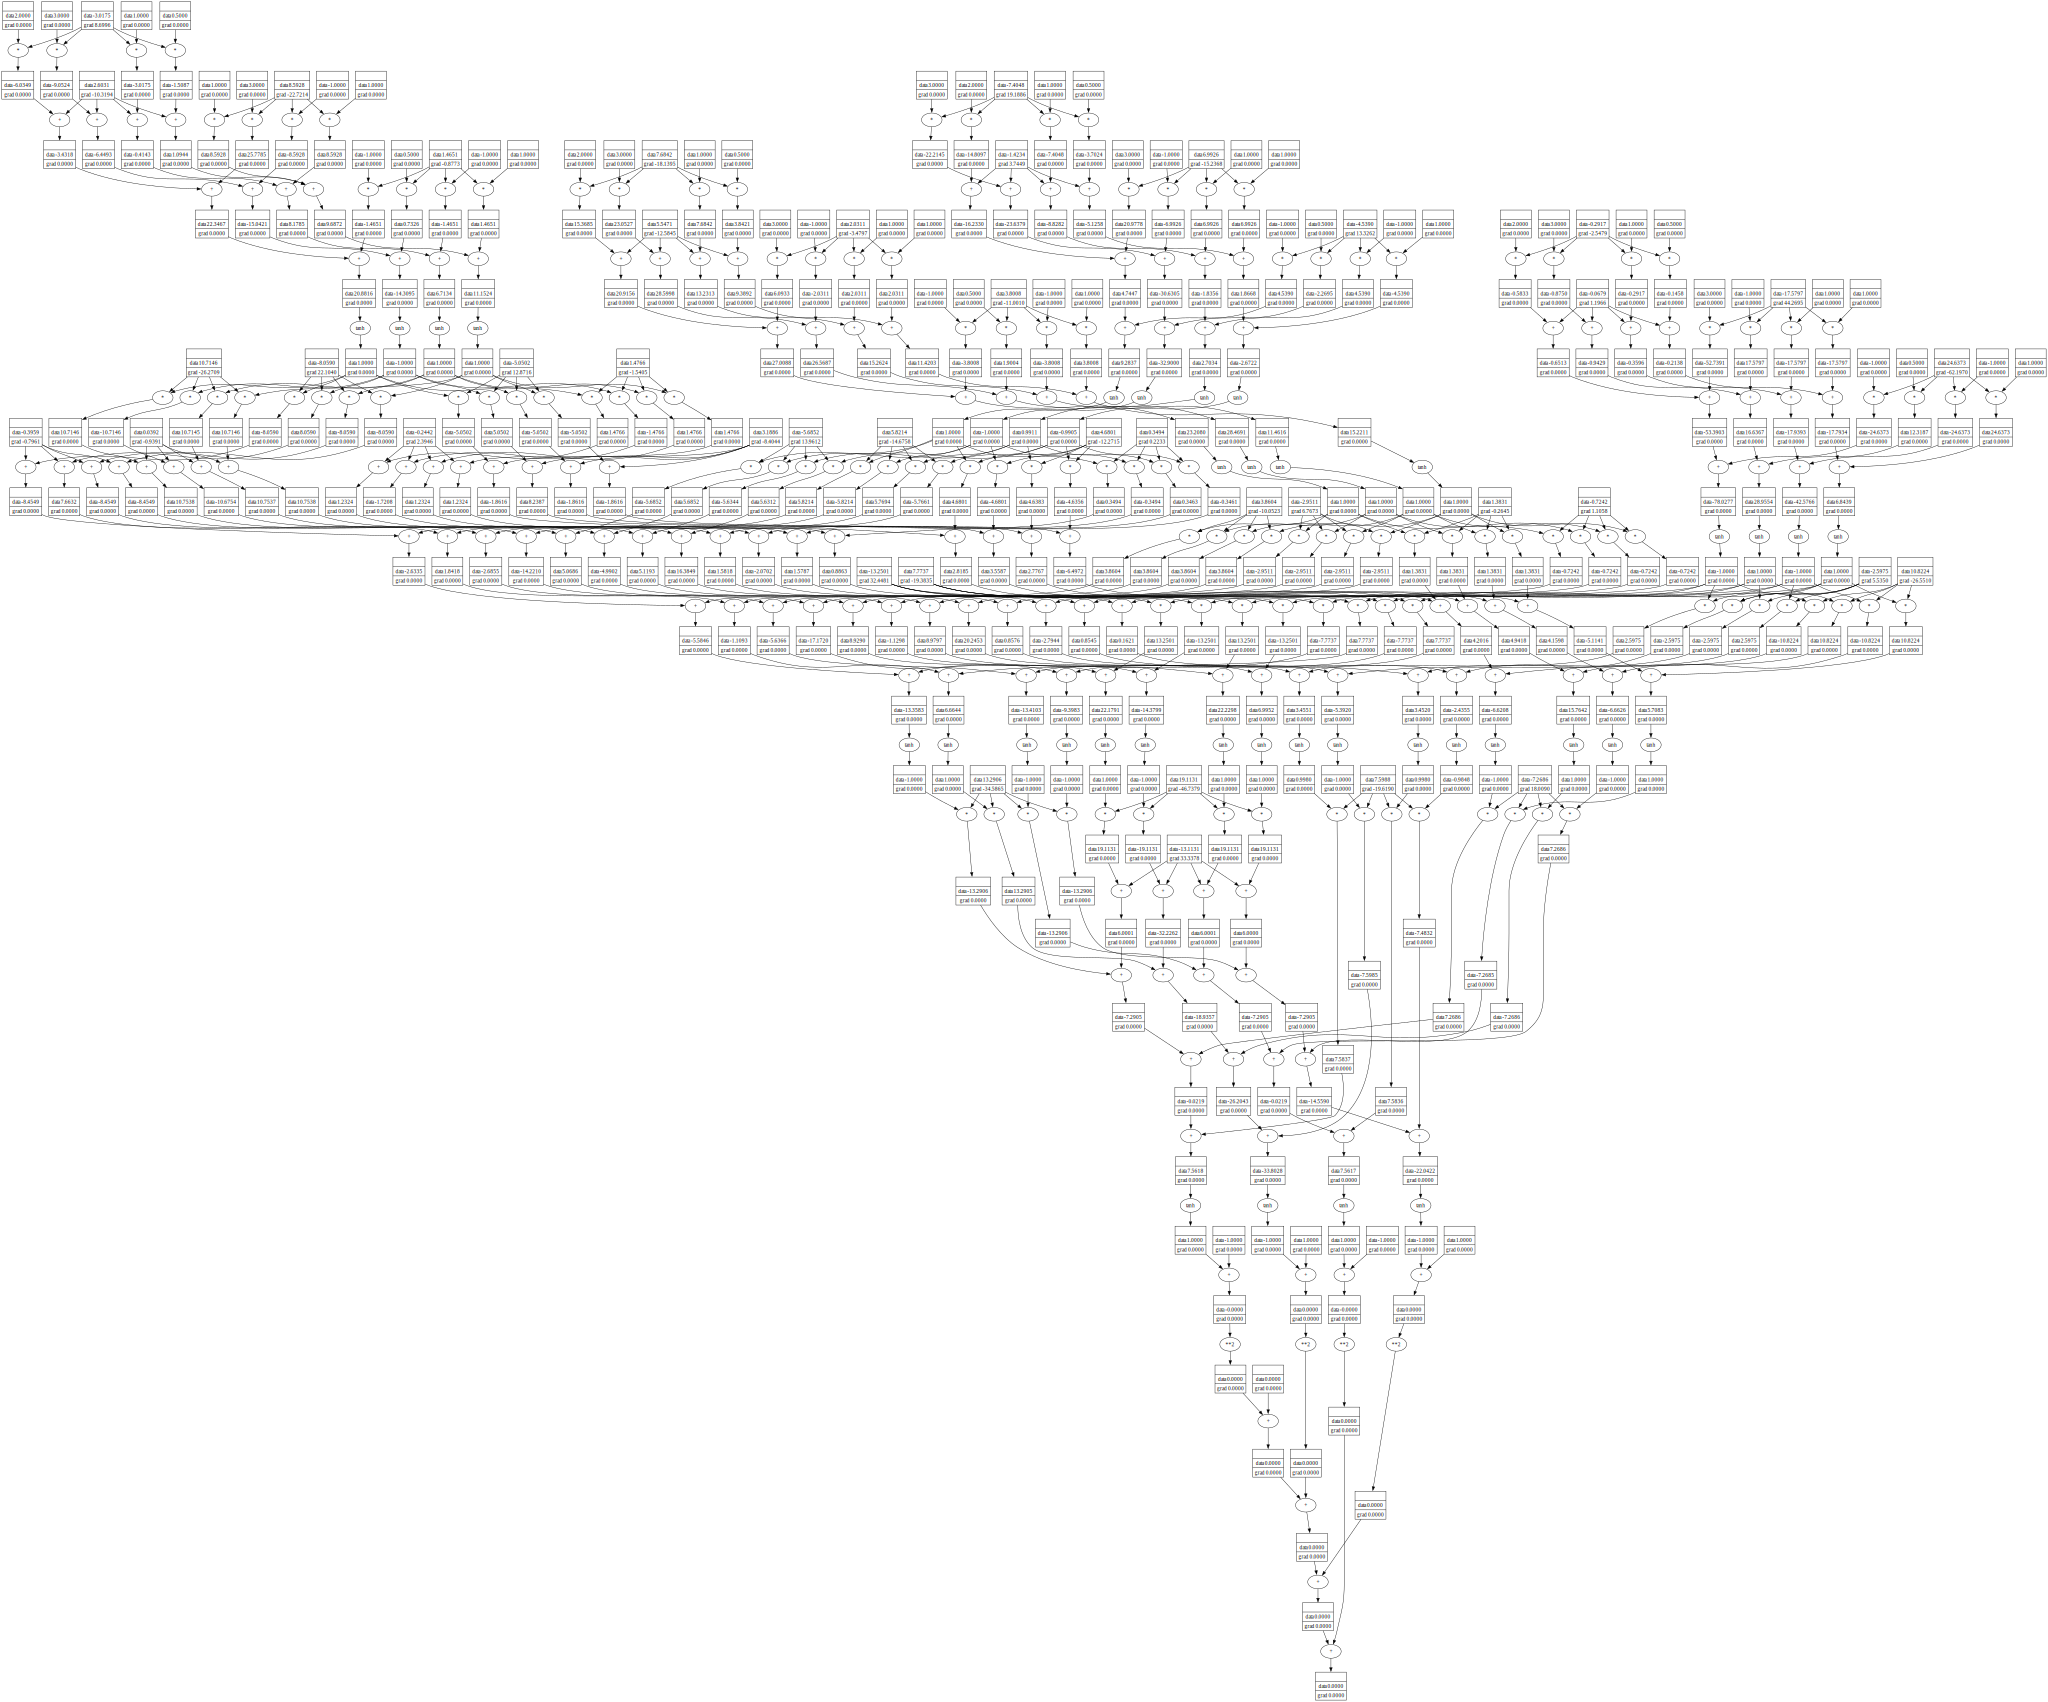

In [23]:
draw_dot(loss, rankdir="TB")